In [2]:
# !pip install pandas numpy scikit-learn matplotlib torch torchvision torchaudio sympy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os # 主要用于路径操作，在Colab中需求较少

# 设置设备 (GPU 或 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available. GPU: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch built with CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")

# 导入 sympy 并打印版本，以便后续调试（如果需要）
import sympy
print(f"Sympy Version: {sympy.__version__}")
print(f"--- Setup Complete ---")

--- Environment Setup ---
Using device: cuda
PyTorch Version: 2.6.0+cu124
CUDA available. GPU: Tesla T4
PyTorch built with CUDA version: 12.4
Sympy Version: 1.13.1
--- Setup Complete ---


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



--- Data and Label Loading ---
Successfully loaded data from: /content/drive/MyDrive/data/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv
Timestamp column processed and set as index.
Successfully loaded label file: /content/drive/MyDrive/labels/combined_windows.json
Raw anomaly windows for key 'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv': [['2014-02-18 16:02:00.000000', '2014-02-19 08:42:00.000000'], ['2014-02-24 10:17:00.000000', '2014-02-25 02:57:00.000000']]
  Processed anomaly window: 2014-02-18 16:02:00.000000 to 2014-02-19 08:42:00.000000. Marked 201 data points as anomalous.
  Processed anomaly window: 2014-02-24 10:17:00.000000 to 2014-02-25 02:57:00.000000. Marked 201 data points as anomalous.
Finished processing labels. Processed 2 anomaly window(s).
Total data points marked as anomalous: 402
Prepared 'time_series_values' (shape: (4032, 1)) and 'true_labels_for_evaluation' (anomalies: 402).


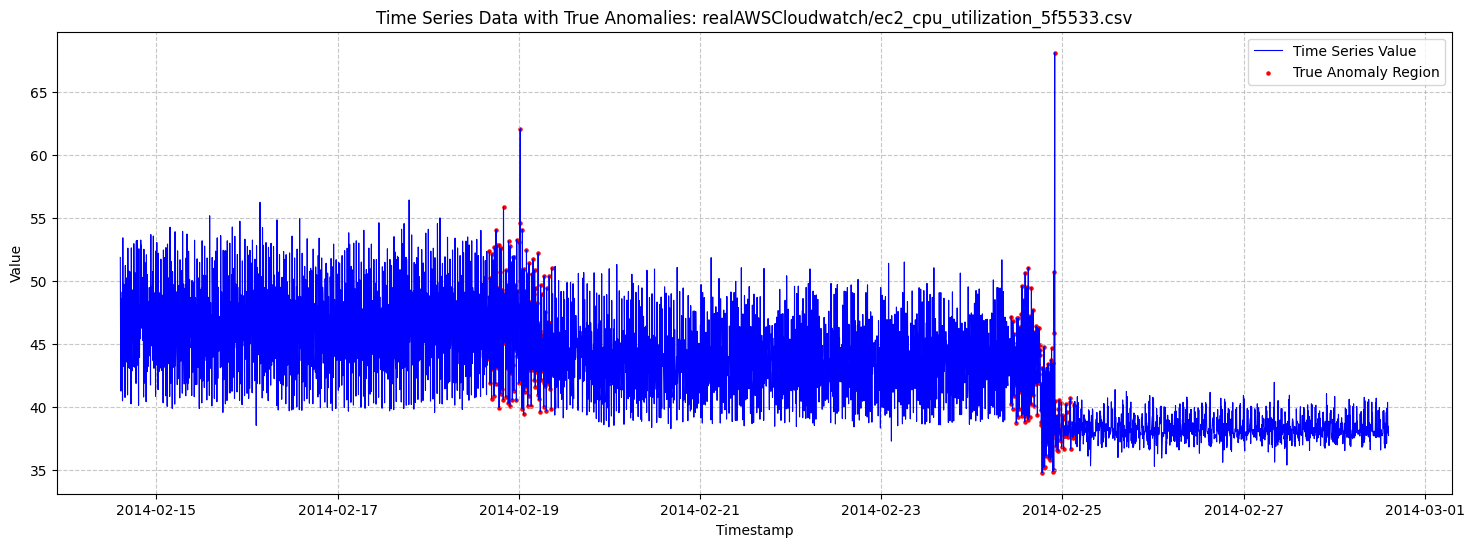

--- Data Loading Complete ---


In [4]:
print(f"\n--- Data and Label Loading ---")
# 假设文件已上传到 Colab 的 /content/ 目录下
DATA_FILE_COLAB_PATH = '/content/drive/MyDrive/data/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv'
LABEL_FILE_COLAB_PATH = '/content/drive/MyDrive/labels/combined_windows.json'

# NAB JSON 文件中使用的键通常是 'category/filename.csv' 格式
# 对于 art_load_balancer_spikes.csv，键是 'artificialWithAnomaly/art_load_balancer_spikes.csv'
JSON_KEY_FOR_LABELS = 'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv'

data_df = None
try:
    data_df = pd.read_csv(DATA_FILE_COLAB_PATH)
    print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
except FileNotFoundError:
    print(f"Error: Data file '{DATA_FILE_COLAB_PATH}' not found. Please make sure you have uploaded it.")
    # 如果你想在此处停止，可以 raise 一个错误
    # raise
except Exception as e:
    print(f"An error occurred while loading data: {e}")
    # raise

if data_df is not None:
    try:
        data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])
        data_df = data_df.set_index('timestamp')
        print("Timestamp column processed and set as index.")
    except Exception as e:
        print(f"Error processing timestamp column: {e}")
        data_df = None # 标记为处理失败

if data_df is not None:
    data_df['is_anomaly'] = 0 # 初始化所有点为正常
    parsed_anomaly_windows_count = 0
    try:
        with open(LABEL_FILE_COLAB_PATH, 'r') as f:
            all_labels_json = json.load(f)
        print(f"Successfully loaded label file: {LABEL_FILE_COLAB_PATH}")

        raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])

        if not raw_anomaly_windows_list:
            print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}' in the label file.")
        else:
            print(f"Raw anomaly windows for key '{JSON_KEY_FOR_LABELS}': {raw_anomaly_windows_list}")
            for window_event in raw_anomaly_windows_list:
                if isinstance(window_event, list) and len(window_event) == 2:
                    try:
                        start_time_str, end_time_str = window_event[0], window_event[1]
                        start_ts = pd.to_datetime(start_time_str)
                        end_ts = pd.to_datetime(end_time_str)

                        anomalous_points_mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                        data_df.loc[anomalous_points_mask, 'is_anomaly'] = 1

                        num_points_in_window = anomalous_points_mask.sum()
                        print(f"  Processed anomaly window: {start_time_str} to {end_time_str}. Marked {num_points_in_window} data points as anomalous.")
                        if num_points_in_window > 0:
                            parsed_anomaly_windows_count += 1
                    except Exception as e:
                        print(f"  Warning: Could not parse or process window event {window_event}: {e}")
                else:
                    print(f"  Warning: Unexpected format for window event: {window_event}")

            total_anomalous_points = data_df['is_anomaly'].sum()
            print(f"Finished processing labels. Processed {parsed_anomaly_windows_count} anomaly window(s).")
            print(f"Total data points marked as anomalous: {total_anomalous_points}")

    except FileNotFoundError:
        print(f"Error: Label file '{LABEL_FILE_COLAB_PATH}' not found. Please upload it.")
    except Exception as e:
        print(f"An error occurred during label processing: {e}")

    if 'value' in data_df.columns and 'is_anomaly' in data_df.columns:
        time_series_values = data_df['value'].values.reshape(-1, 1)
        true_labels_for_evaluation = data_df['is_anomaly'].values
        print(f"Prepared 'time_series_values' (shape: {time_series_values.shape}) and 'true_labels_for_evaluation' (anomalies: {true_labels_for_evaluation.sum()}).")

        # 可视化原始数据和标记的异常
        plt.figure(figsize=(18, 6))
        plt.plot(data_df.index, data_df['value'], label='Time Series Value', color='blue', linewidth=0.8)
        anomalous_data_plot = data_df[data_df['is_anomaly'] == 1]
        if not anomalous_data_plot.empty:
            plt.scatter(anomalous_data_plot.index, anomalous_data_plot['value'], color='red', label='True Anomaly Region', marker='.', s=20)
        plt.title(f"Time Series Data with True Anomalies: {JSON_KEY_FOR_LABELS}")
        plt.xlabel("Timestamp")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("Could not prepare data for modeling (e.g., 'value' or 'is_anomaly' column missing, or data_df is None).")
else:
    print("data_df was not loaded successfully. Cannot proceed.")
print(f"--- Data Loading Complete ---")

In [5]:
print(f"\n--- Data Preprocessing ---")
if 'time_series_values' in locals() and time_series_values is not None: # 确保数据已准备好
    scaler = MinMaxScaler(feature_range=(-1, 1))
    time_series_scaled = scaler.fit_transform(time_series_values)
    print(f"Data scaled. Shape: {time_series_scaled.shape}")

    SEQUENCE_LENGTH = 30  # 可根据数据特性调整

    def create_sequences_colab(input_data, sequence_length):
        sequences = []
        for i in range(len(input_data) - sequence_length + 1):
            seq = input_data[i:(i + sequence_length)]
            sequences.append(seq)
        return np.array(sequences)

    X_sequences = create_sequences_colab(time_series_scaled, SEQUENCE_LENGTH)
    # 对于自编码器，输入和目标（要重构的）是相同的序列
    X_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device) # 目标也是输入序列本身

    print(f"Created sequences. X_tensor shape: {X_tensor.shape}, y_tensor shape: {y_tensor.shape}")

    # 创建 DataLoader
    BATCH_SIZE = 32
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"DataLoader created with batch size {BATCH_SIZE}.")
else:
    print("Skipping preprocessing as 'time_series_values' is not available.")
print(f"--- Preprocessing Complete ---")


--- Data Preprocessing ---
Data scaled. Shape: (4032, 1)
Created sequences. X_tensor shape: torch.Size([4003, 30, 1]), y_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
--- Preprocessing Complete ---


In [6]:
print(f"\n--- LSTM Autoencoder Model Definition ---")
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(LSTMAutoencoder, self).__init__()
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim, # 可以选择不同的解码器隐藏层大小
            num_layers=num_layers,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        encoder_outputs, (hidden, cell) = self.encoder_lstm(x)
        # 使用编码器的输出（所有时间步）作为解码器的输入
        decoder_outputs, _ = self.decoder_lstm(encoder_outputs, (hidden, cell))
        reconstructed_x = self.output_layer(decoder_outputs)
        return reconstructed_x

# 模型参数
INPUT_DIM = 1  # 单变量时间序列
HIDDEN_DIM = 64 # LSTM隐藏单元数量 (可调)
NUM_LAYERS = 2  # LSTM层数 (可调)

if 'X_tensor' in locals(): # 确保模型可以被实例化
    model = LSTMAutoencoder(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
    print(model)
    print(f"Model instantiated and moved to device: {next(model.parameters()).device}")
else:
    print("Cannot instantiate model as X_tensor is not available.")
print(f"--- Model Definition Complete ---")


--- LSTM Autoencoder Model Definition ---
LSTMAutoencoder(
  (encoder_lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (decoder_lstm): LSTM(64, 64, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)
Model instantiated and moved to device: cuda:0
--- Model Definition Complete ---



--- Model Training ---
Starting training for 30 epochs...
Epoch [5/30], Loss: 0.030907
Epoch [10/30], Loss: 0.000112
Epoch [15/30], Loss: 0.000027
Epoch [20/30], Loss: 0.000066
Epoch [25/30], Loss: 0.000046
Epoch [30/30], Loss: 0.000014
Training finished.


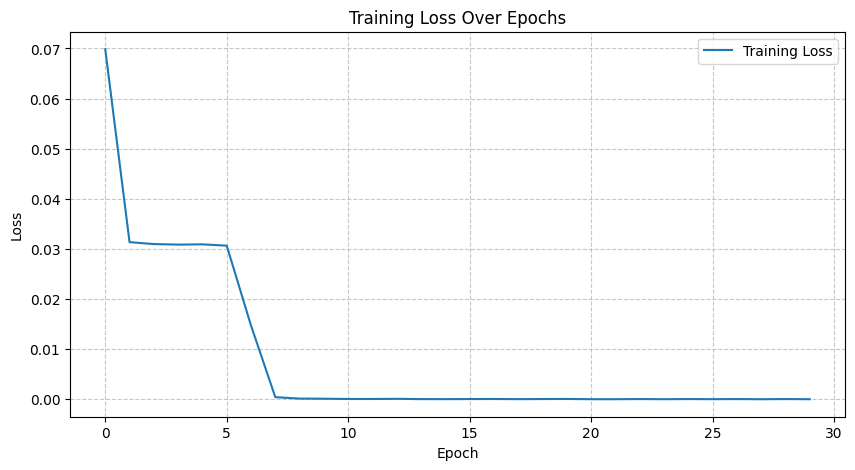

--- Model Training Complete ---


In [7]:
print(f"\n--- Model Training ---")
if 'model' in locals() and 'dataloader' in locals(): # 确保模型和数据加载器已准备好
    NUM_EPOCHS = 30  # 可根据需要调整
    LEARNING_RATE = 0.001

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # 之前本地环境出错的地方

    history = {'train_loss': []}
    print(f"Starting training for {NUM_EPOCHS} epochs...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0
        for seq_in, seq_target in dataloader:
            # 数据已经在创建 DataLoader 时移到了 device
            # seq_in, seq_target = seq_in.to(device), seq_target.to(device)

            optimizer.zero_grad()
            seq_pred = model(seq_in)
            loss = criterion(seq_pred, seq_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_epoch_loss:.6f}")
    print("Training finished.")

    # 可视化训练损失
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Skipping model training as model or dataloader is not available.")
print(f"--- Model Training Complete ---")

In [8]:
print(f"\n--- Anomaly Score Calculation ---")
if 'model' in locals() and 'X_tensor' in locals() and 'scaler' in locals() and 'SEQUENCE_LENGTH' in locals():
    model.eval()
    reconstruction_errors_per_sequence = []
    with torch.no_grad():
        # 我们需要遍历原始的、未组成batch的X_tensor来为每个序列获得误差
        # 或者我们可以用一个batch_size=1的DataLoader
        temp_dataset_for_eval = TensorDataset(X_tensor, y_tensor) # y_tensor在这里不重要
        temp_dataloader_for_eval = DataLoader(temp_dataset_for_eval, batch_size=1, shuffle=False)

        for seq_true_batch, _ in temp_dataloader_for_eval:
            # seq_true_batch 已经加载到 device
            seq_pred_batch = model(seq_true_batch)
            error = criterion(seq_pred_batch, seq_true_batch).item() # MSE for each sequence in the batch (here, batch_size=1)
            reconstruction_errors_per_sequence.append(error)

    reconstruction_errors_per_sequence = np.array(reconstruction_errors_per_sequence)
    print(f"Calculated reconstruction errors for {len(reconstruction_errors_per_sequence)} sequences.")

    # 将序列的重构误差映射回原始时间序列的每个点
    # 序列 i 的误差，我们将其赋给该序列覆盖的最后一个点（即原始数据中的点 i + SEQUENCE_LENGTH - 1）
    anomaly_scores = np.full(len(time_series_scaled), np.nan)
    for i in range(len(reconstruction_errors_per_sequence)):
        anomaly_scores[i + SEQUENCE_LENGTH - 1] = reconstruction_errors_per_sequence[i]

    # 填充开头的NaN值 (简单策略：用第一个有效分数填充)
    first_valid_score_idx = np.where(~np.isnan(anomaly_scores))[0]
    if len(first_valid_score_idx) > 0:
        anomaly_scores[:first_valid_score_idx[0]] = anomaly_scores[first_valid_score_idx[0]]
    else: # 如果所有都是NaN (不太可能)
        anomaly_scores[:] = 0 # 或其他默认值

    print("Anomaly scores mapped to original time series points.")
else:
    print("Skipping anomaly score calculation as prerequisites are not met.")
print(f"--- Anomaly Score Calculation Complete ---")


--- Anomaly Score Calculation ---
Calculated reconstruction errors for 4003 sequences.
Anomaly scores mapped to original time series points.
--- Anomaly Score Calculation Complete ---


In [9]:
print(f"\n--- Thresholding and Evaluation ---")
if 'anomaly_scores' in locals() and 'true_labels_for_evaluation' in locals():
    # 移除评估中不需要的NaN值 (通常是序列开头的部分)
    # true_labels_for_evaluation 应该与 time_series_scaled 同长度
    valid_indices_for_eval = ~np.isnan(anomaly_scores)
    eval_scores = anomaly_scores[valid_indices_for_eval]
    eval_true_labels = true_labels_for_evaluation[valid_indices_for_eval]

    if len(eval_scores) > 0 and len(eval_true_labels) > 0:
        # 设定阈值 (例如，取异常分数的95百分位数)
        # 这个阈值需要根据实际情况和数据分布仔细调整
        threshold = np.quantile(eval_scores, 0.95)
        print(f"Anomaly threshold (95th percentile of scores): {threshold:.6f}")

        # 根据阈值得出预测结果
        predicted_anomalies_bool = eval_scores > threshold
        predicted_anomalies_int = predicted_anomalies_bool.astype(int)

        # 计算评估指标
        precision, recall, f1, _ = precision_recall_fscore_support(eval_true_labels, predicted_anomalies_int, average='binary', zero_division=0)
        cm = confusion_matrix(eval_true_labels, predicted_anomalies_int)

        print(f"Evaluation Results (for the 'valid' part of the series):")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  Confusion Matrix:\n{cm}")
        # TN FP
        # FN TP
    else:
        print("Not enough data for evaluation (eval_scores or eval_true_labels is empty).")
else:
    print("Skipping thresholding and evaluation as prerequisites are not met.")
print(f"--- Thresholding and Evaluation Complete ---")


--- Thresholding and Evaluation ---
Anomaly threshold (95th percentile of scores): 0.000025
Evaluation Results (for the 'valid' part of the series):
  Precision: 0.3762
  Recall:    0.1891
  F1-Score:  0.2517
  Confusion Matrix:
[[3504  126]
 [ 326   76]]
--- Thresholding and Evaluation Complete ---



--- Final Visualization ---


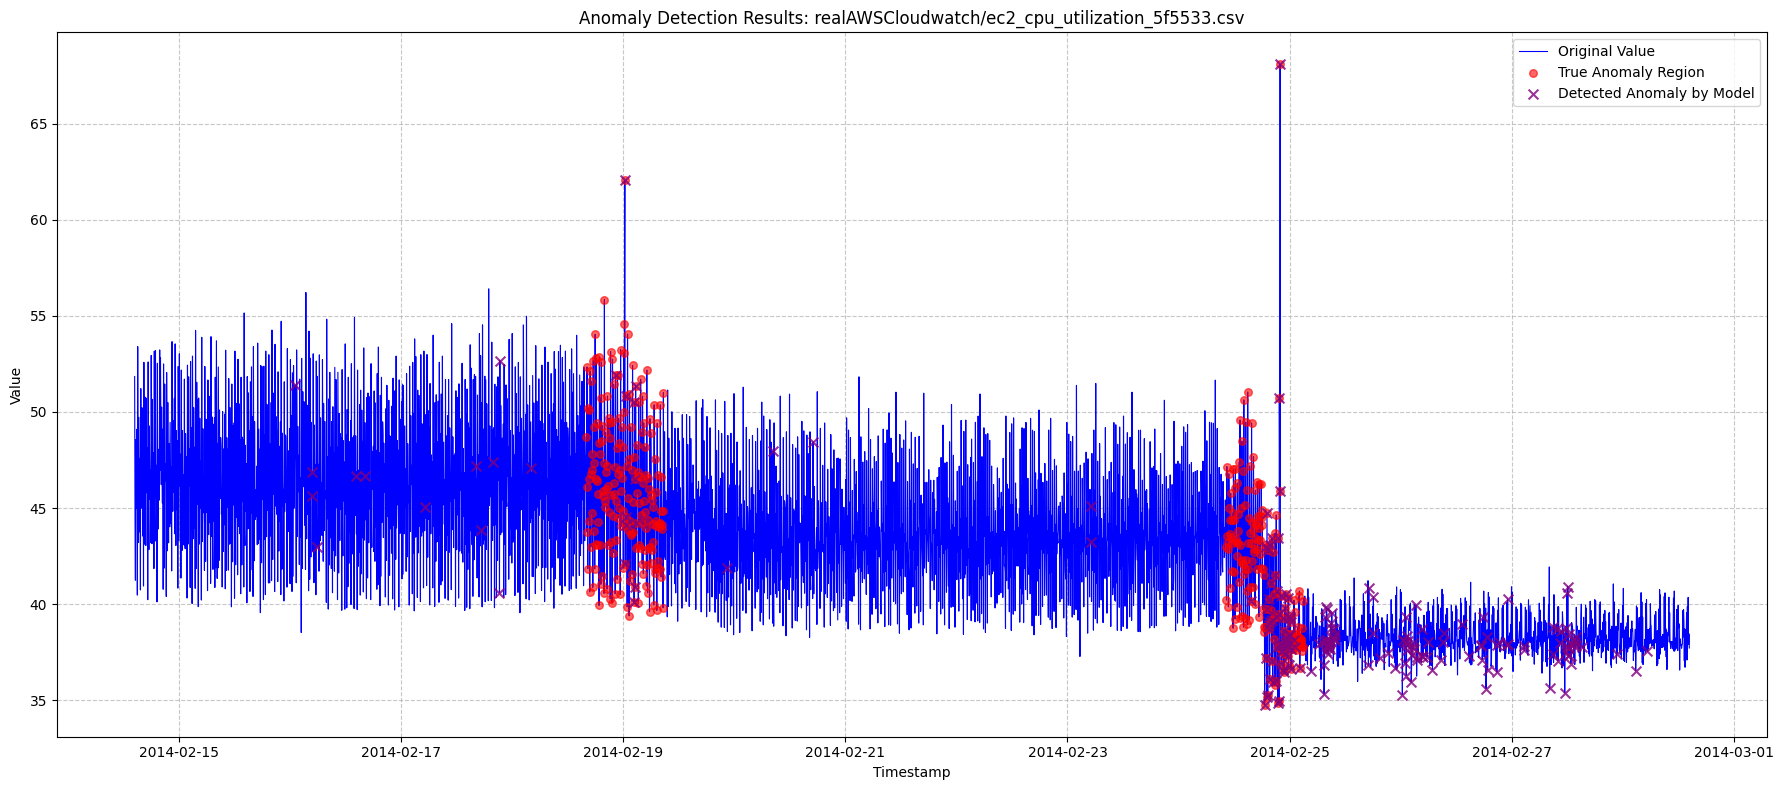

--- Visualization Complete ---


In [10]:
print(f"\n--- Final Visualization ---")
if 'data_df' in locals() and 'anomaly_scores' in locals() and 'threshold' in locals() and 'scaler' in locals():
    # 创建一个与 data_df 等长的预测标签数组
    final_predicted_labels_on_df = np.full(len(data_df), 0, dtype=int)
    # 将 eval_scores > threshold 的结果放回对应位置
    # 注意：valid_indices_for_eval 是相对于原始 anomaly_scores 数组的
    # 我们需要将 predicted_anomalies_bool (长度为 eval_scores) 映射回原始长度

    # 一个简单的方法是直接在完整的 anomaly_scores 上应用阈值
    # 但要注意，开头的 anomaly_scores 是填充的，可能不准确
    # 更准确的是使用 valid_indices_for_eval 来定位

    # 创建一个完整的预测异常序列 (与原始数据对齐)
    # 初始化为全0 (正常)
    predicted_anomalies_full = np.zeros_like(true_labels_for_evaluation, dtype=int)
    # 将有效部分的预测结果填入
    if 'predicted_anomalies_bool' in locals(): # 确保已计算
         predicted_anomalies_full[valid_indices_for_eval] = predicted_anomalies_bool.astype(int)


    plt.figure(figsize=(18, 8))
    # 绘制原始数据 (逆归一化)
    original_values_plot = scaler.inverse_transform(time_series_scaled)
    plt.plot(data_df.index, original_values_plot, label='Original Value', color='blue', linewidth=0.8)

    # 标记真实异常区域
    true_anomalies_plot_df = data_df[data_df['is_anomaly'] == 1]
    if not true_anomalies_plot_df.empty:
        plt.scatter(true_anomalies_plot_df.index,
                    true_anomalies_plot_df['value'],
                    color='red', label='True Anomaly Region', marker='o', s=30, alpha=0.6, zorder=3)

    # 标记检测到的异常点
    # data_df.index 的长度应该等于 predicted_anomalies_full 的长度
    detected_anomalies_indices = data_df.index[predicted_anomalies_full == 1]
    if len(detected_anomalies_indices) > 0:
        plt.scatter(detected_anomalies_indices,
                    original_values_plot[predicted_anomalies_full == 1], # 使用原始值绘制
                    color='purple', label='Detected Anomaly by Model', marker='x', s=50, alpha=0.8, zorder=4)

    # 绘制异常分数和阈值（可选，可能需要第二个y轴）
    # fig, ax1 = plt.subplots(figsize=(18,8))
    # ax1.plot(data_df.index, original_values_plot, label='Original Value', color='blue', linewidth=0.8)
    # ax1.scatter(true_anomalies_plot_df.index, true_anomalies_plot_df['value'], color='red', label='True Anomaly Region', marker='o', s=30, alpha=0.6, zorder=3)
    # ax1.scatter(detected_anomalies_indices, original_values_plot[predicted_anomalies_full == 1], color='purple', label='Detected Anomaly', marker='x', s=50, alpha=0.8, zorder=4)
    # ax1.set_xlabel("Timestamp")
    # ax1.set_ylabel("Value")
    # ax1.legend(loc='upper left')

    # ax2 = ax1.twinx()
    # ax2.plot(data_df.index, anomaly_scores, label='Anomaly Score', color='orange', alpha=0.5, linestyle='--')
    # ax2.axhline(y=threshold, color='green', linestyle=':', linewidth=2, label=f'Threshold ({threshold:.4f})')
    # ax2.set_ylabel("Anomaly Score")
    # ax2.legend(loc='upper right')
    # plt.title(f"Anomaly Detection Results: {JSON_KEY_FOR_LABELS} (with Scores & Threshold)")

    plt.title(f"Anomaly Detection Results: {JSON_KEY_FOR_LABELS}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping final visualization as prerequisites are not met.")
print(f"--- Visualization Complete ---")